In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import os

In [6]:
dataset ="archive (2)"

print(os.listdir(dataset))

['brain_tumor_dataset', 'no', 'yes']


In [7]:
dataAug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
train_data = dataAug.flow_from_directory(
    dataset,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)
val_data = dataAug.flow_from_directory(
    dataset,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 406 images belonging to 3 classes.
Found 100 images belonging to 3 classes.


In [8]:
model = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    keras.layers.MaxPooling2D(2,2),
    
    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1,activation='sigmoid')
])
model.summary()

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 480ms/step - accuracy: 0.2094 - loss: 0.7625 - val_accuracy: 0.1900 - val_loss: 0.2884
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - accuracy: 0.1946 - loss: 0.5377 - val_accuracy: 0.1900 - val_loss: 0.4222
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 399ms/step - accuracy: 0.1946 - loss: 0.5116 - val_accuracy: 0.1900 - val_loss: 0.3297
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 403ms/step - accuracy: 0.1946 - loss: 0.5058 - val_accuracy: 0.1900 - val_loss: 0.4105
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 393ms/step - accuracy: 0.1970 - loss: 0.5464 - val_accuracy: 0.1900 - val_loss: 0.4546
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 401ms/step - accuracy: 0.1970 - loss: 0.5432 - val_accuracy: 0.1900 - val_loss: 0.4906
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 403ms/step - accuracy: 0.1946 - loss: 0.5555 - val_accuracy: 0.1900 - val_loss: 0.4929
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - accuracy: 0.1946 - loss: 0.5009 - val_accuracy: 0.

In [12]:
print(train_data.class_indices)

{'brain_tumor_dataset': 0, 'no': 1, 'yes': 2}


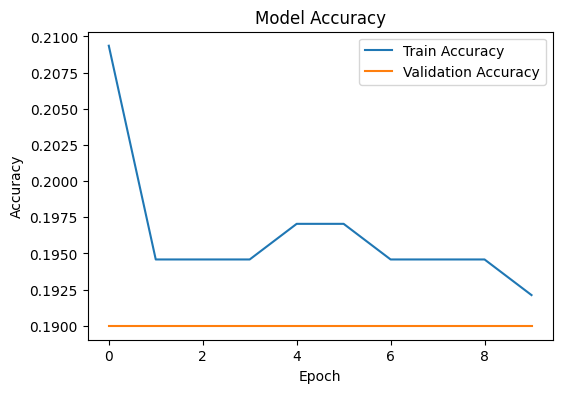

In [13]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

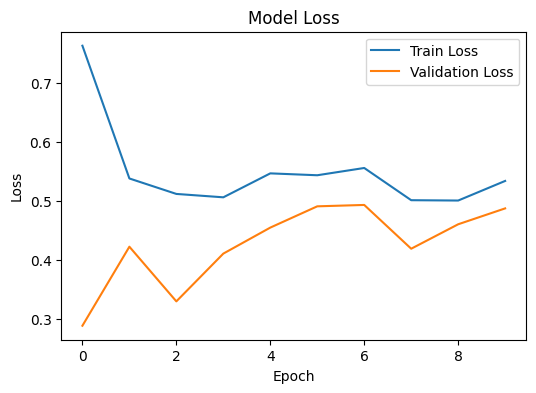

In [14]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step


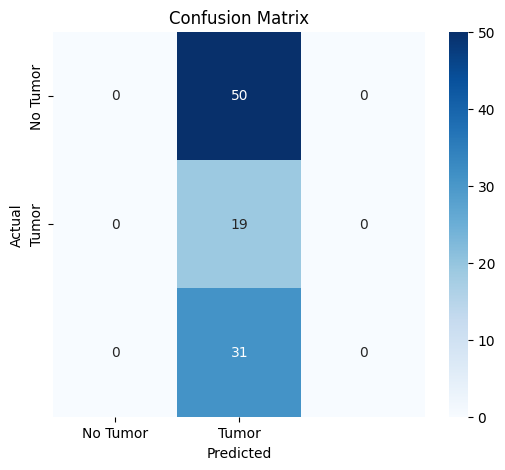

In [16]:

predictions = model.predict(val_data)
y_pred = (predictions > 0.5).astype(int)
y_true = val_data.classes

cm = confusion_matrix(y_true,y_pred)



plt.figure(figsize=(6,5))
sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Blues',
xticklabels=['No Tumor','Tumor'],
yticklabels=['No Tumor','Tumor'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
print(classification_report(
y_true,
y_pred,
labels=[0,1], 
target_names=['No Tumor','Tumor']
))

              precision    recall  f1-score   support

    No Tumor       0.00      0.00      0.00        50
       Tumor       0.19      1.00      0.32        19

   micro avg       0.19      0.28      0.22        69
   macro avg       0.10      0.50      0.16        69
weighted avg       0.05      0.28      0.09        69



c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

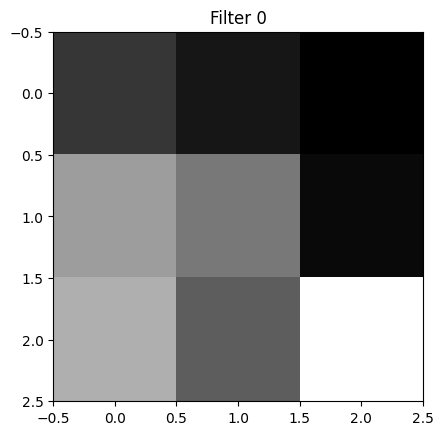

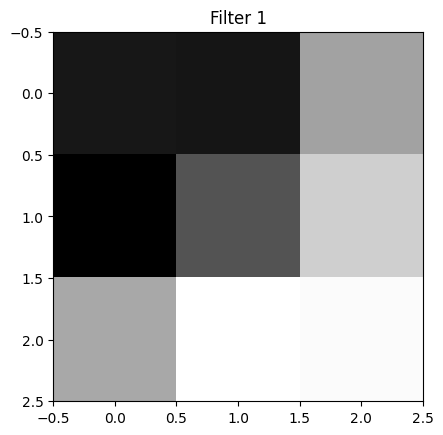

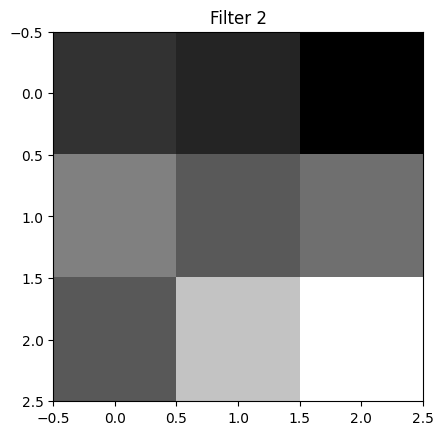

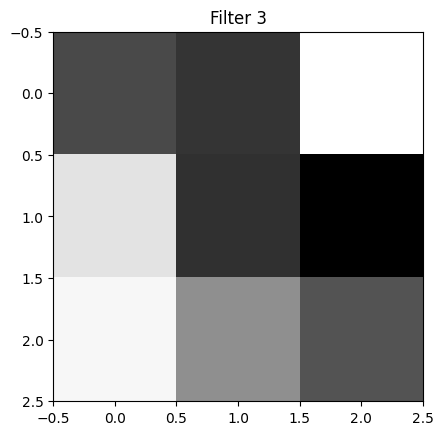

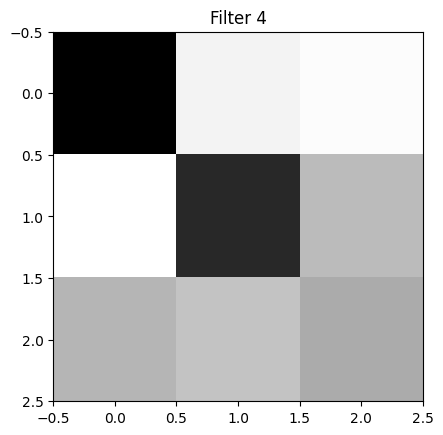

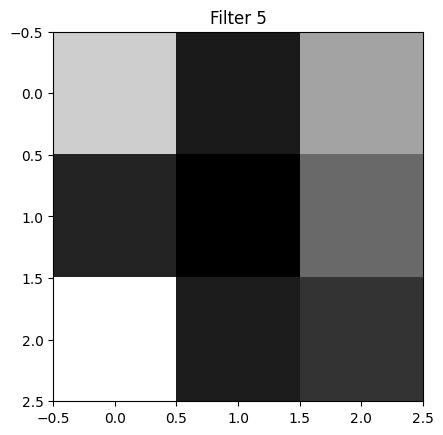

In [18]:
filters, biases = model.layers[0].get_weights()

for i in range(6):
    f = filters[:,:,:,i]
    plt.imshow(f[:,:,0], cmap="gray")
    plt.title("Filter "+str(i))
    plt.show()

**CAM**

In [19]:
img_path = "archive (2)/yes/Y1.jpg"

img = keras.preprocessing.image.load_img(img_path,target_size=(224,224))
img_array = keras.preprocessing.image.img_to_array(img)/255
img_array = np.expand_dims(img_array,axis=0)

**GRAD CAM**

In [20]:
_=model.predict(img_array)
last_conv_layer = model.layers[4]

grad_model = tf.keras.models.Model(
    [model.inputs],
    [last_conv_layer.output, model.outputs]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[0][:,0]

grads = tape.gradient(loss, conv_outputs)
# Average gradients
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

# Weighted sum
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
# Normalize
heatmap = np.maximum(heatmap,0)/np.max(heatmap)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
